In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.linalg import lu

In [3]:
data = pd.read_csv("student_scores.csv")

scores = data.drop("student_id", axis=1)
A = scores.values

#### PART A : VECTOR FUNDAMENTALS

In [10]:
# 1. Represent student scores as vectors

print("Student vectors (first 5):")
for i in range(5):
    print("Student", i+1, "vector:", A[i])

Student vectors (first 5):
Student 1 vector: [78 82 75 80 85 90]
Student 2 vector: [65 70 68 72 74 78]
Student 3 vector: [92 88 90 85 87 95]
Student 4 vector: [55 60 58 62 65 66]
Student 5 vector: [80 85 82 79 88 91]


In [15]:
# 2A. Compute Norm-1 and Norm-2 of vectors

print("Norms of student vectors:")

for i in range(len(A)):
    v = A[i]

    norm1 = np.linalg.norm(v, ord=1)
    norm2 = np.linalg.norm(v)

    if i < 5:
        print("Student", i+1, "L1:", norm1, "L2:", norm2)


print("\nInterpretation: Norms measure magnitude of the score vectors. Larger norms indicate higher overall scores.")

Norms of student vectors:
Student 1 L1: 490.0 L2: 200.39461070597682
Student 2 L1: 427.0 L2: 174.62244987400675
Student 3 L1: 537.0 L2: 219.37866806050218
Student 4 L1: 366.0 L2: 149.71305888265059
Student 5 L1: 505.0 L2: 206.43400882606528

Interpretation: Norms measure magnitude of the score vectors. Larger norms indicate higher overall scores.


In [16]:
# 2B. Dot product and angle between two students score vectors

print("Dot products between students:")

for i in range(len(A)):
    for j in range(i+1, len(A)):

        v1 = A[i]
        v2 = A[j]

        dot = np.dot(v1, v2)

        angle = np.arccos(dot / (np.linalg.norm(v1) * np.linalg.norm(v2)))

        if i < 2 and j < 3:
            print("Students", i+1, "and", j+1)
            print("Dot product:", dot)
            print("Angle:", angle)

print("\nInterpretation: Dot product measures similarity between student score patterns. Smaller angle means more similar performance.")

Dot products between students:
Students 1 and 2
Dot product: 34980
Angle: 0.02767282933476907
Students 1 and 3
Dot product: 43887
Angle: 0.05853859659904737
Students 2 and 3
Dot product: 38228
Angle: 0.0648158285117834

Interpretation: Dot product measures similarity between student score patterns. Smaller angle means more similar performance.


C:\Users\BHOOMI\AppData\Local\Temp\ipykernel_30088\3394381642.py:13: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos(dot / (np.linalg.norm(v1) * np.linalg.norm(v2)))


In [17]:
# 2C. Cross product (for 3D selected subjects)

for i in range(len(A)):
    for j in range(i+1, len(A)):

        v1 = A[i][:3]
        v2 = A[j][:3]

        cross = np.cross(v1, v2)

        if i < 2 and j < 3:
            print("Students", i+1, "and", j+1, "cross product:", cross)

print("\nInterpretation: Cross product represents a vector perpendicular to the two selected subject vectors.")

Students 1 and 2 cross product: [ 326 -429  130]
Students 1 and 3 cross product: [ 780 -120 -680]
Students 2 and 3 cross product: [ 316  406 -720]

Interpretation: Cross product represents a vector perpendicular to the two selected subject vectors.


In [18]:
# 3. Find the projection of one vector onto another

print("Vector projections between students:")

for i in range(len(A)):
    for j in range(i+1, len(A)):

        v1 = A[i]
        v2 = A[j]

        proj = (np.dot(v1, v2) / np.dot(v2, v2)) * v2

        if i < 2 and j < 3:
            print("Projection of student", i+1, "onto student", j+1)
            print(proj)

print("\nInterpretation: Projection shows how much one student's performance aligns with another student's score direction.")

Vector projections between students:
Projection of student 1 onto student 2
[74.56465418 80.30039681 78.00609976 82.59469386 84.88899092 89.47758502]
Projection of student 1 onto student 3
[83.8947784  80.24717934 82.07097887 77.51148004 79.33527957 86.63047769]
Projection of student 2 onto student 3
[73.07698381 69.89972365 71.48835373 67.51677852 69.10540861 75.45992894]

Interpretation: Projection shows how much one student's performance aligns with another student's score direction.


#### PART B : MATRIX OPERATIONS

In [19]:
# 4. Form a matrix of students subjects

print("Matrix shape:", A.shape)


Matrix shape: (100, 6)


In [20]:
# 4A. Matrix addition

add = A + A
print("Matrix addition (first 3):")
print(add[:3])

Matrix addition (first 3):
[[156 164 150 160 170 180]
 [130 140 136 144 148 156]
 [184 176 180 170 174 190]]


In [21]:
# 4B. Matrix multiplication

mult = np.dot(A.T, A)
print("Matrix multiplication shape:", mult.shape)
print("Matrix multiplication")
print(mult)

Matrix multiplication shape: (6, 6)
Matrix multiplication
[[558460 580484 563957 575082 589682 614757]
 [580484 603650 586386 598168 613573 639534]
 [563957 586386 569747 581098 596045 621244]
 [575082 598168 581098 593153 608354 634009]
 [589682 613573 596045 608354 624579 650688]
 [614757 639534 621244 634009 650688 678085]]


In [25]:
# 4C. Transpose

transpose = A.T
print("Transpose shape:", transpose.shape)
print("Transpose (first 3):")
print(transpose[:3])

Transpose shape: (6, 100)
Transpose (first 3):
[[78 65 92 55 80 72 60 88 74 50 83 67 91 58 76 69 85 62 90 73 81 64 87 59
  77 71 66 89 74 52 84 68 93 57 79 70 63 88 75 54 82 66 91 60 78 72 65 87
  76 58 79 68 90 57 82 74 63 88 76 54 81 69 91 60 78 72 65 87 75 55 83 70
  92 59 80 73 66 89 77 56 84 71 93 61 79 74 67 90 78 57 85 72 94 62 81 75
  68 91 79 58]
 [82 70 88 60 85 75 63 90 78 55 86 72 89 62 80 74 87 66 92 77 84 68 90 63
  81 73 69 91 76 57 86 71 94 61 83 72 67 89 78 58 85 70 93 64 82 75 69 90
  79 62 83 72 91 60 85 76 67 90 79 58 84 73 93 64 82 74 69 89 78 59 86 73
  94 63 83 76 70 91 80 60 87 74 95 65 82 77 71 92 81 61 88 75 96 66 84 78
  72 93 82 62]
 [75 68 90 58 82 70 65 85 76 52 84 69 92 60 78 72 83 64 89 74 80 66 86 61
  79 70 67 87 73 54 83 69 91 59 80 71 65 87 76 56 83 68 90 62 80 73 67 88
  77 60 81 70 89 59 83 75 65 87 77 56 82 71 90 62 80 73 67 88 76 57 84 71
  91 61 81 74 68 88 78 58 85 72 92 63 80 75 69 89 79 59 86 73 93 64 82 76
  70 90 80 60]]


In [27]:
# 4D. Determinant and Inverse

square_matrix = np.dot(A.T, A)

print("Square matrix shape:", square_matrix.shape)

det = np.linalg.det(square_matrix)
print("Determinant:", det)

inverse = np.linalg.inv(square_matrix)
print("Inverse (first 3):")
print(inverse[:3])

print("\nInterpretation: Matrix operations help analyze relationships between subject scores across all students.")


Square matrix shape: (6, 6)
Determinant: 1.0904005108072859e+17
Inverse (first 3):
[[ 0.01463025 -0.01006698 -0.00977916  0.00134187  0.00732661 -0.00309508]
 [-0.01006698  0.01742184 -0.00088197 -0.00161275 -0.00228493 -0.00279599]
 [-0.00977916 -0.00088197  0.01459868 -0.00196749 -0.00584884  0.00377489]]

Interpretation: Matrix operations help analyze relationships between subject scores across all students.


#### PART C : LINEAR TRANSFORMATIONS & GEOMETRY

In [ ]:
# 5. Explain line, plane, and hyperplane
print("2 subjects represent points on a line in 2D space.")
print("3 subjects represent points on a plane in 3D space.")
print("6 subjects represent points in higher dimensional space (hyperplane).")
print("\n")

# 6. Show dimensionality increase
print("Dataset dimensions:")
print("2D → 2 subjects")
print("3D → 3 subjects")
print("Higher dimensions → all subjects together")

print("\nDataset dimension =",A.shape[1])
print("Each student vector exists in 6-dimensional space.")

2 subjects represent points on a line in 2D space.
3 subjects represent points on a plane in 3D space.
6 subjects represent points in higher dimensional space (hyperplane).


Dataset dimensions:
2D → 2 subjects
3D → 3 subjects
Higher dimensions → all subjects together

Dataset dimension = 6
Each student vector exists in 6-dimensional space.


#### PART D : EIGENVALUES & DECOMPOSITION

In [33]:
cov_matrix = np.cov(A, rowvar=False)

# 7. Compute eigenvalues and eigenvectors of covariance matrix

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:", eigenvalues)

print("\nInterpretation: Eigenvalues represent the variance captured along different directions of the dataset.")


Eigenvalues: [6.13193179e+02 2.38234090e+00 1.29098735e+00 8.57155563e-01
 2.79932439e-01 3.82263313e-01]

Interpretation: Eigenvalues represent the variance captured along different directions of the dataset.


In [34]:
# 8. Perform LU Decomposition of the dataset matrix

P, L, U = lu(cov_matrix)
print("LU Decomposition:\n")
print(L,"\n")
print(U,"\n")

print("Interpretation: LU decomposition factors the matrix into lower and upper triangular matrices for efficient calculations.")

LU Decomposition:

[[ 1.          0.          0.          0.          0.          0.        ]
 [ 0.92545981  1.          0.          0.          0.          0.        ]
 [ 0.90972253  0.32209152  1.          0.          0.          0.        ]
 [ 0.80437342  0.54069123  0.2927094   1.          0.          0.        ]
 [ 0.70488789  0.87048589  0.50400957 -0.15255958  1.          0.        ]
 [ 0.80140318  0.64179279  0.01311315 -0.06248162  0.40910423  1.        ]] 

[[ 1.36573333e+02  1.26393131e+02  1.24243838e+02  1.09855960e+02
   9.62688889e+01  1.09450303e+02]
 [ 0.00000000e+00  9.43792084e-01  3.03987425e-01  5.10300105e-01
   8.21557697e-01  6.05718954e-01]
 [ 0.00000000e+00  0.00000000e+00  9.12143937e-01  2.66993102e-01
   4.59729269e-01  1.19610847e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  2.17475999e+00
  -3.31780472e-01 -1.35882520e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.24667662e+00  5.10020674e-01]
 [ 0.00000000e+00  0.00

In [35]:
# 9. Perform Singular Value Decomposition (SVD)

U1, S, V1 = np.linalg.svd(A)
print("Singular values:", S)
print("SVD helps reduce dimensions by keeping only largest singular values.")

print("\nInterpretation: Larger singular values represent directions containing more information in the dataset.")

Singular values: [1904.22186738   35.09136874   14.9233044     9.23683426    6.72662735
    5.32953906]
SVD helps reduce dimensions by keeping only largest singular values.

Interpretation: Larger singular values represent directions containing more information in the dataset.


#### PART E : DIMENSIONALITY REDUCTION

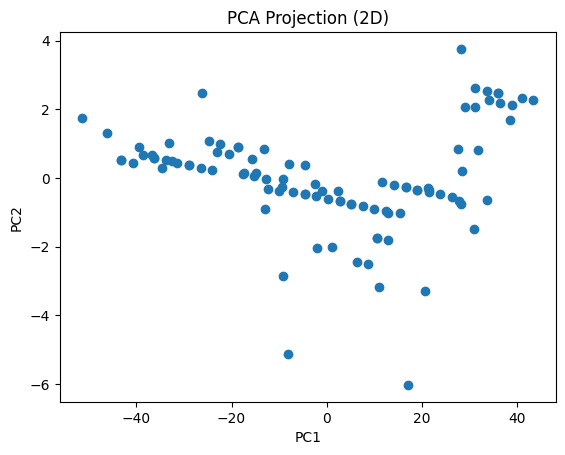

Interpretation: PCA reduces the 6-subject dataset into 2 components while preserving maximum variance.


In [38]:
# 10. Apply PCA to reduce dataset to 2 dimensions

pca = PCA(n_components=2)
pca_result = pca.fit_transform(A)

plt.scatter(pca_result[:,0], pca_result[:,1])
plt.title("PCA Projection (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("Interpretation: PCA reduces the 6-subject dataset into 2 components while preserving maximum variance.")

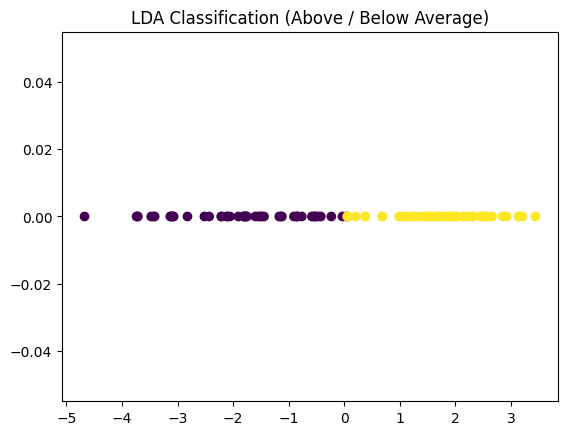

Interpretation: LDA separates students into Above Average and Below Average groups based on score patterns.


In [39]:
# 11. Apply LDA to classify students

avg = scores.mean(axis=1)
labels = np.where(avg >= avg.mean(), 1, 0)
lda = LinearDiscriminantAnalysis(n_components=1)
lda_result = lda.fit_transform(A, labels)

plt.scatter(lda_result, np.zeros(len(lda_result)), c=labels)
plt.title("LDA Classification (Above / Below Average)")
plt.show()

print("Interpretation: LDA separates students into Above Average and Below Average groups based on score patterns.")